In [2]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [4]:
kpoints = bandstructkpoints2q(interpolate = 5);

In [7]:
export_hwannier("wannier", spin=Val('u'))
export_hwannier("wannier", spin=Val('d'))
export_momentum("wannier", spin=Val('u'))
export_momentum("wannier", spin=Val('d'));
export_heph("wannier", spin=Val('u'));
export_heph("wannier", spin=Val('d'));

In [6]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt")
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
Pwannier = pwannier("wannierUp");
Heph, celleph_map = hephwannier("wannierUp"), np.loadtxt("wannierUp.mapeph.txt");
lattice_vectors = loadlattice("wannier.out");

In [6]:
force_matrix, cellph_map = phonon_force_matrix("../../BN44BC_Buckled/phonon");
phonon_bands_bn44bc = phonon_dispersion(force_matrix, cellph_map, kpointsfile="../bandstruct.kpoints", return_negative=true);

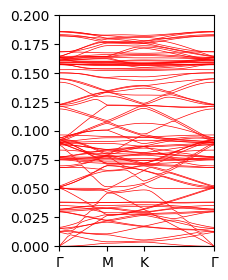

(0.0, 0.2)

In [7]:
figure(figsize=(2, 3))
plot(phonon_bands_bn44bc, color="red", linewidth=0.5)
label_plots()
ylim(0, 0.2)

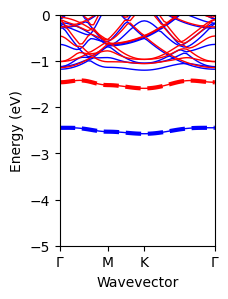

(0.0, 55.0)

In [8]:
figure(figsize=(2, 3))
plot_bands(HwannierUp, cell_mapUp, linewidth=3, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, linewidth=3, color="red", linestyle="dashed")
plot_bands("../BN44BC.bands.eigenvals", spin=2, linewidth=1)
ylim(-5, 0)
label_plots()

In [4]:
x, y = density_of_states(HwannierUp, cell_mapUp, mesh=20, num_blocks=1000, monte_carlo=true, histogram_width=1000)

([-3.5771768144193694, -3.5761766358226885, -3.5751764572260076, -3.5741762786293267, -3.573176100032646, -3.572175921435965, -3.571175742839284, -3.570175564242603, -3.569175385645922, -3.568175207049241  …  -1.4577983680524982, -1.4567981894558173, -1.4557980108591364, -1.4547978322624555, -1.4537976536657746, -1.4527974750690937, -1.4517972964724128, -1.450797117875732, -1.4497969392790506, -1.4487967606823697], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

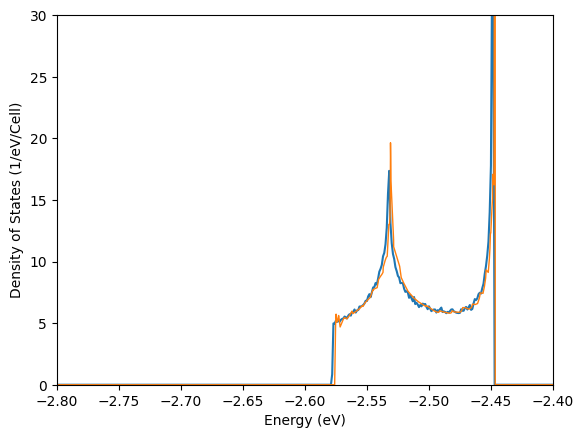

(0.0, 30.0)

In [10]:
plot(x, y)
density_of_states("../DOS/BN44BC.dosUp", linewidth=1)
xlim(-2.8, -2.4)
ylim(0, 30)

In [10]:
e, n = find_chemical_potential(x, y);

In [6]:
# The DOS at the fermi level
μ = e[argmin(abs.(n .- 0.5))]
gμ = y[argmin(abs.(x .- μ))]

println("The chemical potential is: $μ")
println("The DOS at μ is: $gμ")

The chemical potential is: -2.5129867875508696
The DOS at μ is: 7.182500000000001


In [17]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(HwannierUp, cell_mapUp, lattice_vectors, k, -2.514, Val(2), histogram_width=1000, mesh=100, num_blocks=20, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0058823529412, 0.0, 0.0]
3
[0.0117647058824, 0.0, 0.0]
4
[0.0176470588236, 0.0, 0.0]
5
[0.0235294117648, 0.0, 0.0]
6
[0.029411764706, 0.0, 0.0]
7
[0.0352941176472, 0.0, 0.0]
8
[0.0411764705884, 0.0, 0.0]
9
[0.0470588235296, 0.0, 0.0]
10
[0.0529411764708, 0.0, 0.0]
11
[0.058823529412, 0.0, 0.0]
12
[0.0647058823532, 0.0, 0.0]
13
[0.0705882352944, 0.0, 0.0]
14
[0.0764705882356, 0.0, 0.0]
15
[0.0823529411768, 0.0, 0.0]
16
[0.088235294118, 0.0, 0.0]
17
[0.0941176470592, 0.0, 0.0]
18
[0.1000000000004, 0.0, 0.0]
19
[0.1058823529416, 0.0, 0.0]
20
[0.1117647058828, 0.0, 0.0]
21
[0.117647058824, 0.0, 0.0]
22
[0.123529411765, 0.0, 0.0]
23
[0.129411764706, 0.0, 0.0]
24
[0.135294117647, 0.0, 0.0]
25
[0.14117647058799998, 0.0, 0.0]
26
[0.147058823529, 0.0, 0.0]
27
[0.1529411764702, 0.0, 0.0]
28
[0.1588235294114, 0.0, 0.0]
29
[0.1647058823526, 0.0, 0.0]
30
[0.1705882352938, 0.0, 0.0]
31
[0.176470588235, 0.0, 0.0]
32
[0.1823529411762, 0.0, 0.0]
33
[0.1882352941174, 0.0, 0.0]
34


In [18]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_default = zeros(50, 200)
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    for (j, ω) in enumerate(range(0.01, 0.5, length=200))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, 
                smooth(real.(polarizations[i]), win_len=20), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

In [35]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_quadgk = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.01, 0.5, length=100)[1:100])
    x = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:quadgk), rtol=1e-7, atol=1e-7, δ=0.01, normalized=true))
     epsilons_quadgk[i, j] = x
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [41]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_scipy = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.01, 0.5, length=100))
       epsilons_scipy[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:scipy), limit=50, δ=0.001, normalized=true))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [25]:
plasmon_default = [range(0.01, 0.5, length=200)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:50, :])))];
plasmon_default = [0, plasmon_default...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default);
plasmon_default = smooth(plasmon_default, win_len=10);
plasmon_default[1] = 0;

In [51]:
plasmon_quadgk = [range(0.01, 0.5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_quadgk[2:50, :])))];
plasmon_quadgk = [0, plasmon_quadgk...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_quadgk);
plasmon_quadgk = smooth(plasmon_quadgk, win_len=10);
plasmon_quadgk[1] = 0;

In [52]:
plasmon_scipy = [range(0.01, 0.5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_scipy[2:50, :])))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_scipy);
plasmon_scipy = smooth(plasmon_scipy, win_len=10);
plasmon_scipy[1] = 0;

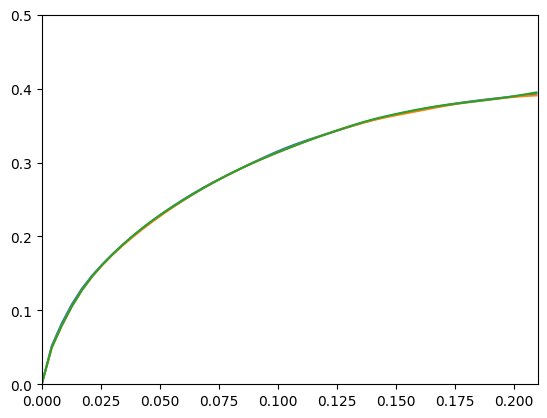

(0.0, 0.5)

In [53]:
plot(qs, plasmon_default)
plot(qs, plasmon_quadgk)
plot(qs, plasmon_scipy)

xlim(0, 0.21)
ylim(0, 0.5)

In [54]:
np.savetxt("plasmon.txt", hcat(qs, plasmon_default, plasmon_scipy, plasmon_quadgk), header="qs, default, scipy, quadgk")

In [7]:
qs, plasmon_default, plasmon_scipy, plasmon_quadgk = [collect(x) for x in eachcol(np.loadtxt("plasmon.txt"))];

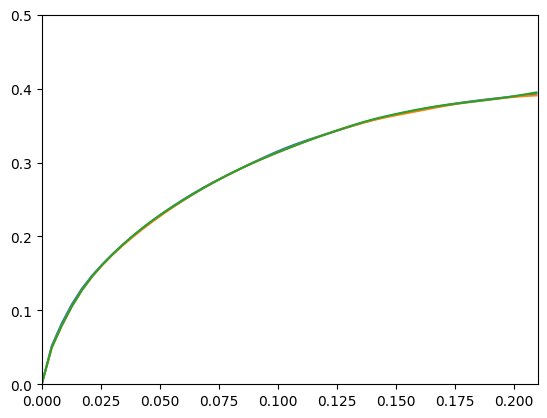

(0.0, 0.5)

In [8]:
plot(qs, plasmon_default)
plot(qs, plasmon_quadgk)
plot(qs, plasmon_scipy)

xlim(0, 0.21)
ylim(0, 0.5)

In [22]:
es, cs = drude_conductivity(lattice_vectors, HwannierUp, cell_mapUp, Pwannier, mesh=20, num_blocks=100, histogram_width=500)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100


([-100.0, -99.9979999799998, -99.9959999599996, -99.9939999399994, -99.9919999199992, -99.989999899999, -99.9879998799988, -99.9859998599986, -99.9839998399984, -99.9819998199982  …  99.9819998199982, 99.9839998399984, 99.9859998599986, 99.9879998799988, 99.989999899999, 99.9919999199992, 99.9939999399994, 99.9959999599996, 99.9979999799998, 100.0], [0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0])

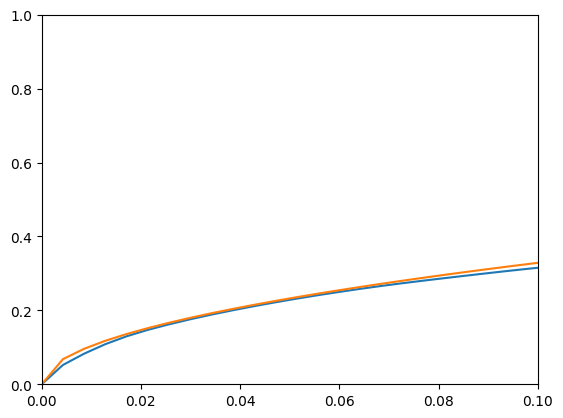

(0.0, 1.0)

In [51]:
plot(qs, plasmon_default)
plot(qs, sqrt.(e²ϵ/8*0.04755*qs))
xlim(0, 0.1)
ylim(0,1)
#plot(es, (smooth(cs[:, 1, 1]+cs[:, 2, 2], win_len=10))/2)
#xlim(-2.52, -2.5)

In [37]:
(smooth(cs[:, 1, 1], win_len=10)[argmin(abs.(es .+ 2.514))]+smooth(cs[:, 2, 2], win_len=10)[argmin(abs.(es .+ 2.514))])/2

0.047550439555685414

In [54]:
println("The conductivity is $(100*0.047550439555685414/(2/pi))% of graphene at 0.5 eV doping") 

The conductivity is 7.46920557915534% of graphene at 0.5 eV doping


In [6]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += 1 ./ np.loadtxt("tau/tau.out-$i")
end
tau_allen_inv *= 1/N 
tau_allen = 1 ./ tau_allen_inv;

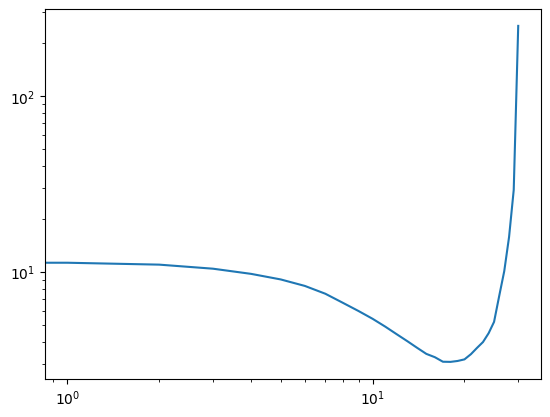

In [9]:
loglog(tau_allen);

In [10]:
omegas = 0.01:0.01:1;
np.savetxt("tau_allen.txt", hcat(omegas, tau_allen))

In [11]:
omegas, tau_allen = [col for col in eachcol(np.loadtxt("tau_allen.txt"))];

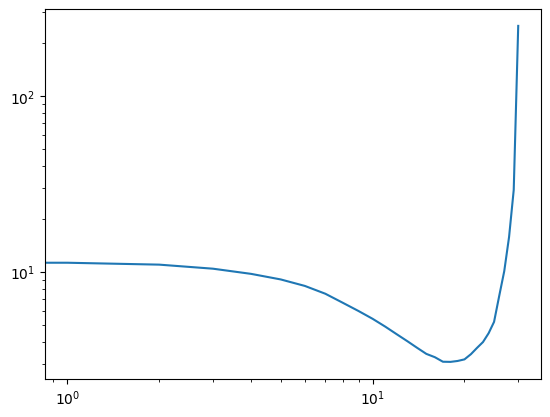

In [13]:
loglog(tau_allen);